In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported")

Libraries imported


In [24]:
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
print("Plot styles configured")

Plot styles configured


In [25]:
df = pd.read_csv('/tmp/df_clean.csv')
feature_cols = df.columns.drop('Potability').tolist()
print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (3276, 10)


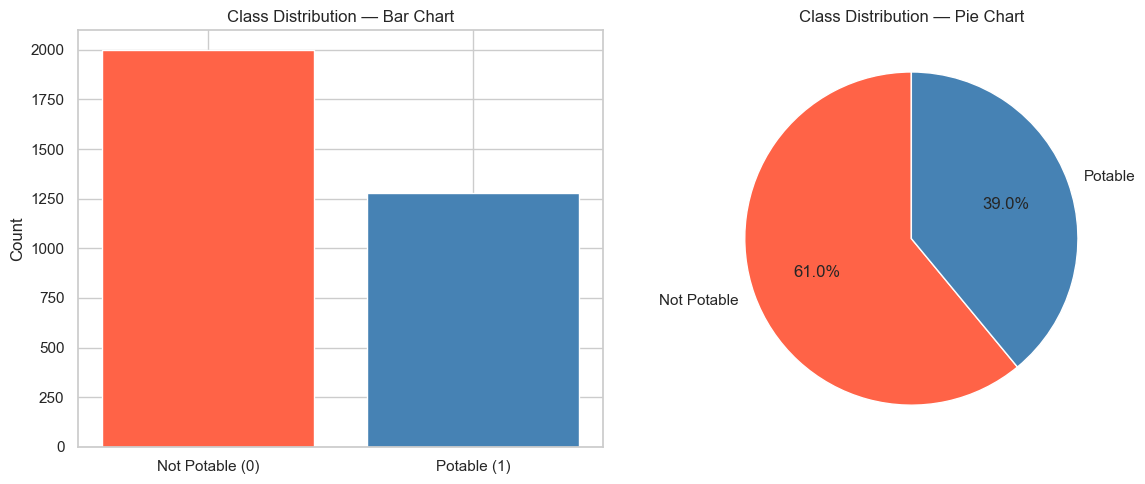

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['Potability'].value_counts()
axes[0].bar(['Not Potable (0)', 'Potable (1)'], counts.values, color=['tomato','steelblue'])
axes[0].set_title('Class Distribution — Bar Chart')
axes[0].set_ylabel('Count')
axes[1].pie(counts.values, labels=['Not Potable', 'Potable'],
            autopct='%1.1f%%', colors=['tomato','steelblue'], startangle=90)
axes[1].set_title('Class Distribution — Pie Chart')
plt.tight_layout()
plt.show()

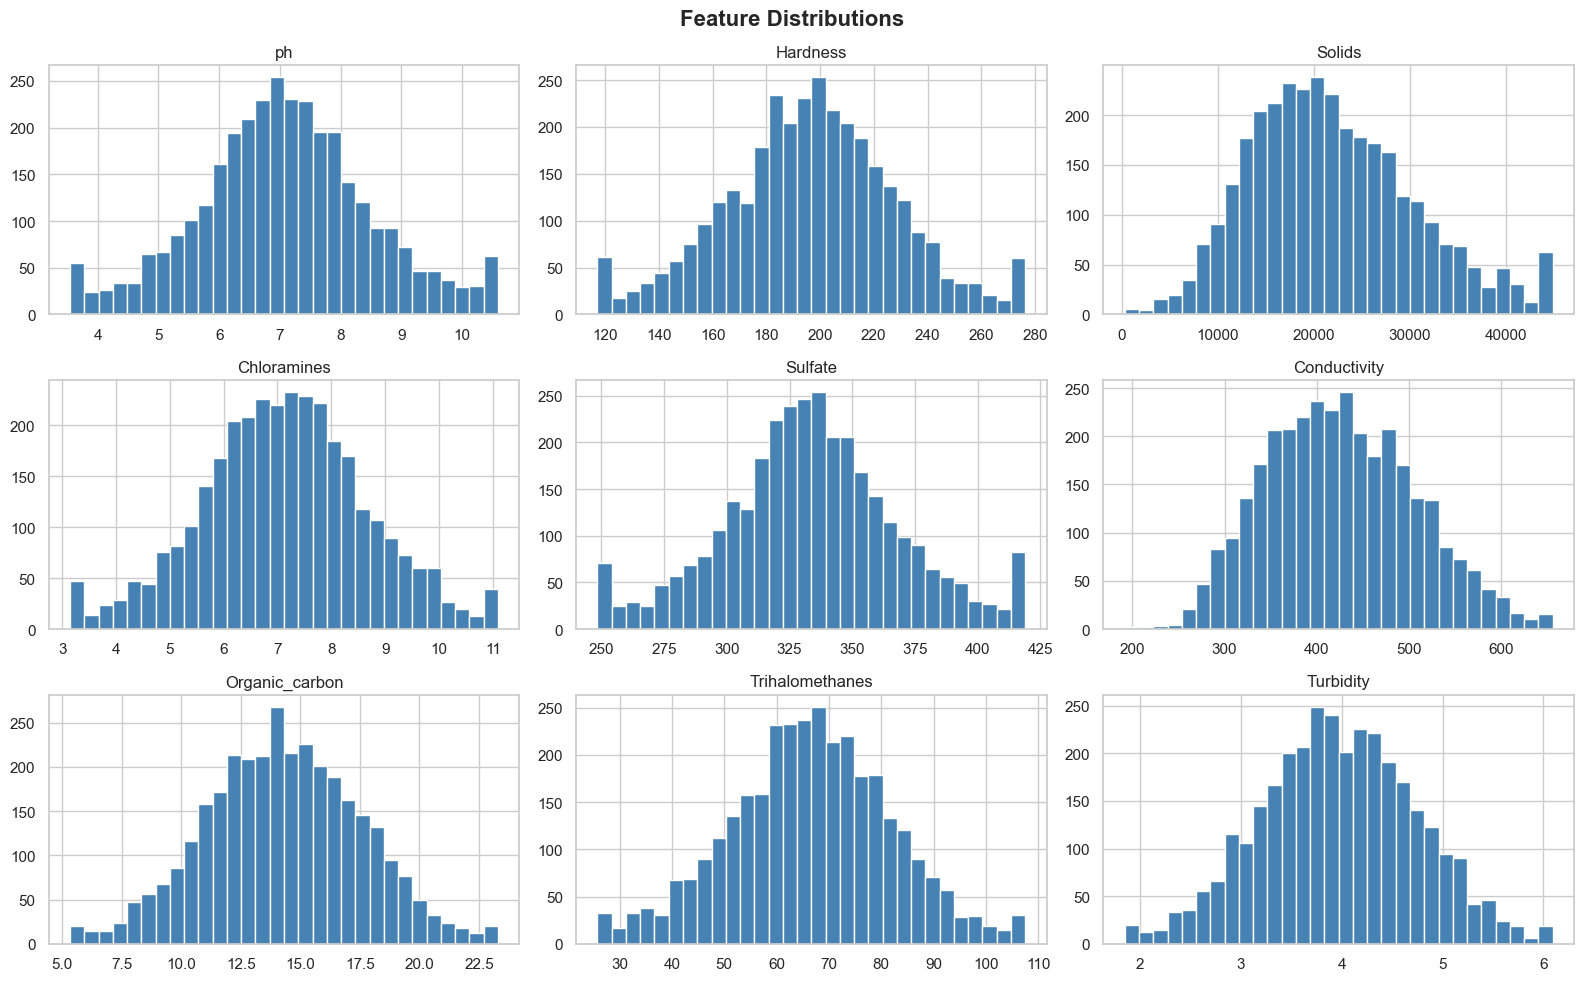

In [27]:
df[feature_cols].hist(bins=30, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

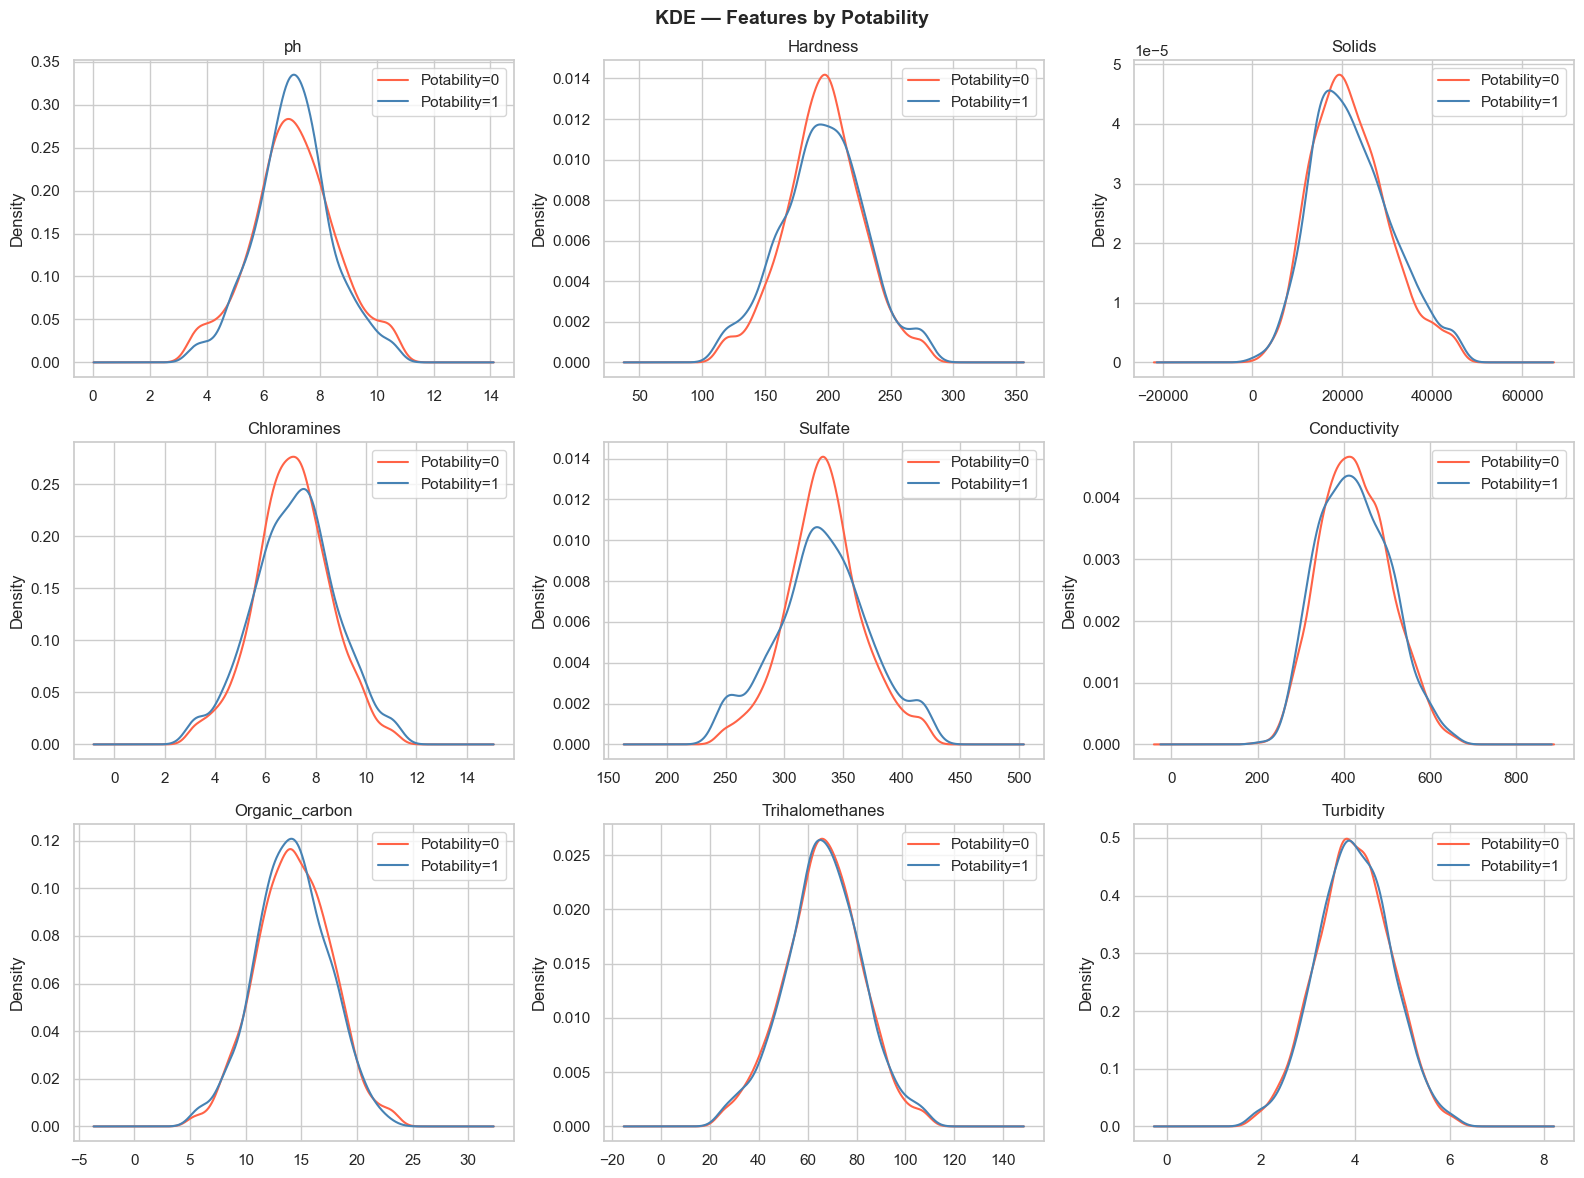

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    for label, color in zip([0, 1], ['tomato', 'steelblue']):
        subset = df[df['Potability'] == label][col]
        subset.plot.kde(ax=axes[i], label=f'Potability={label}', color=color)
    axes[i].set_title(col)
    axes[i].legend()
plt.suptitle('KDE — Features by Potability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

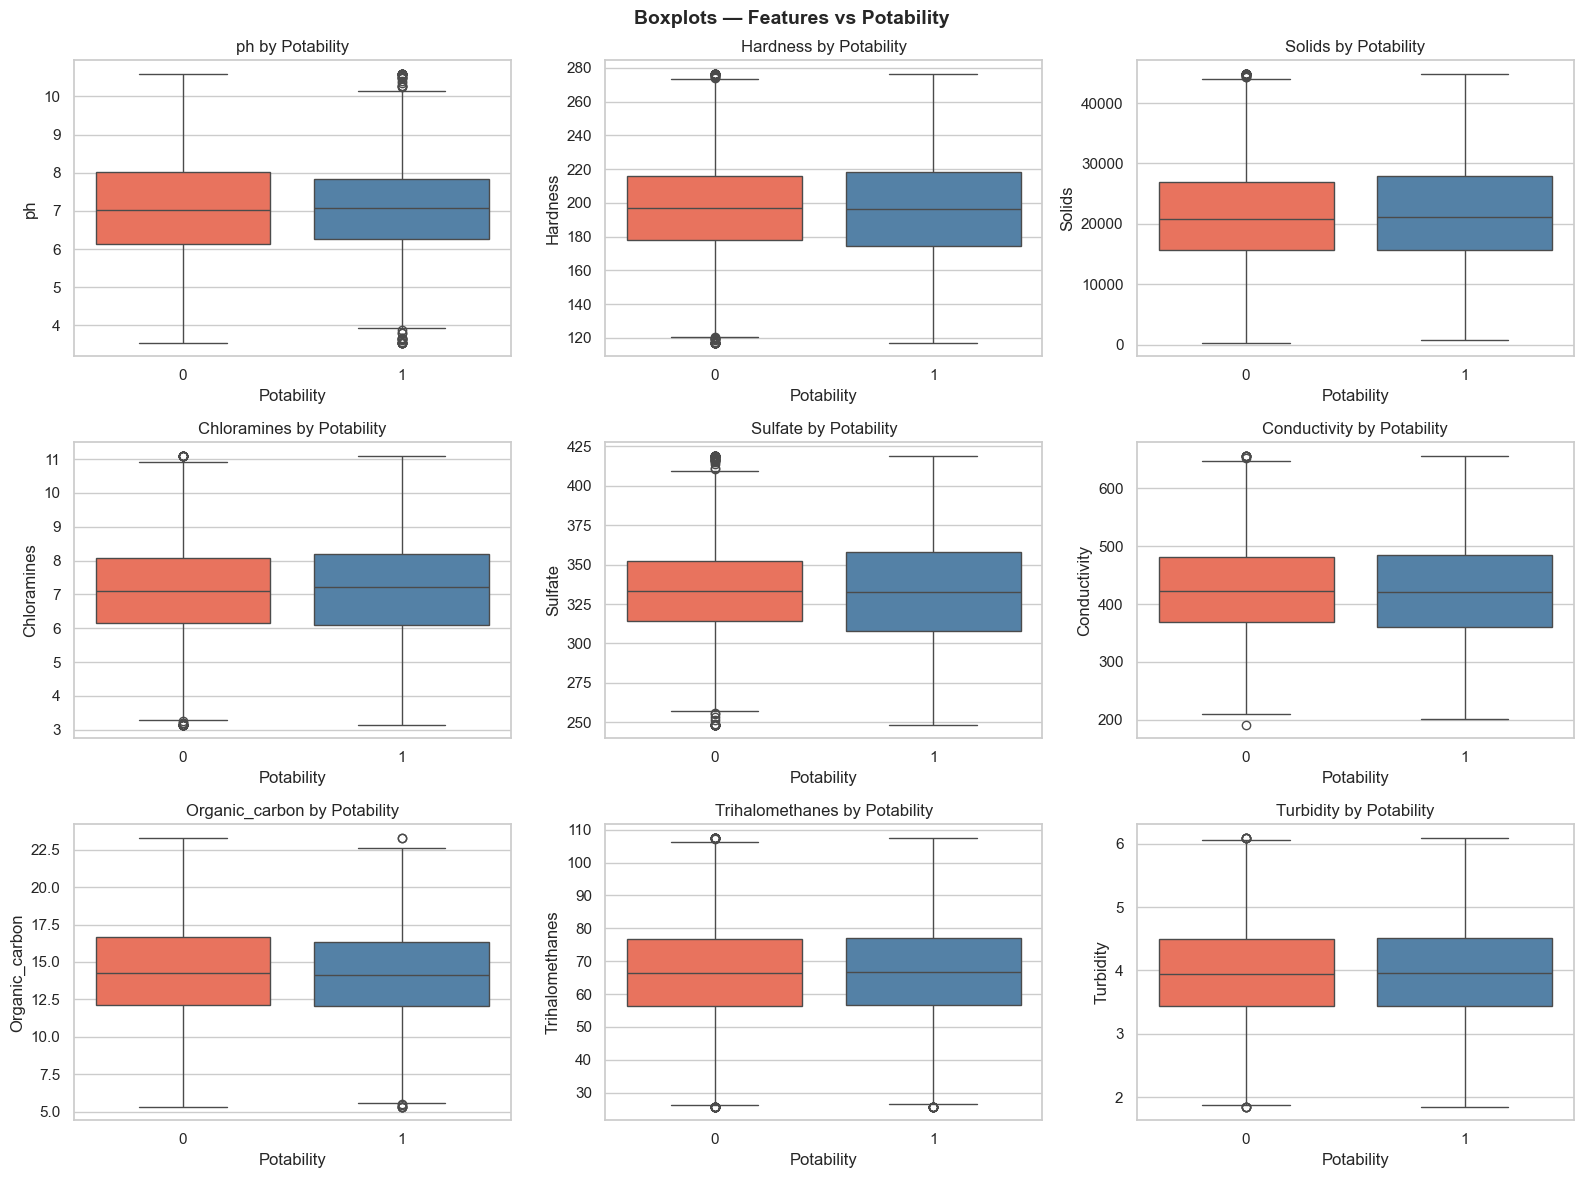

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x='Potability', y=col,
                palette=['tomato','steelblue'], ax=axes[i])
    axes[i].set_title(f'{col} by Potability')
plt.suptitle('Boxplots — Features vs Potability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

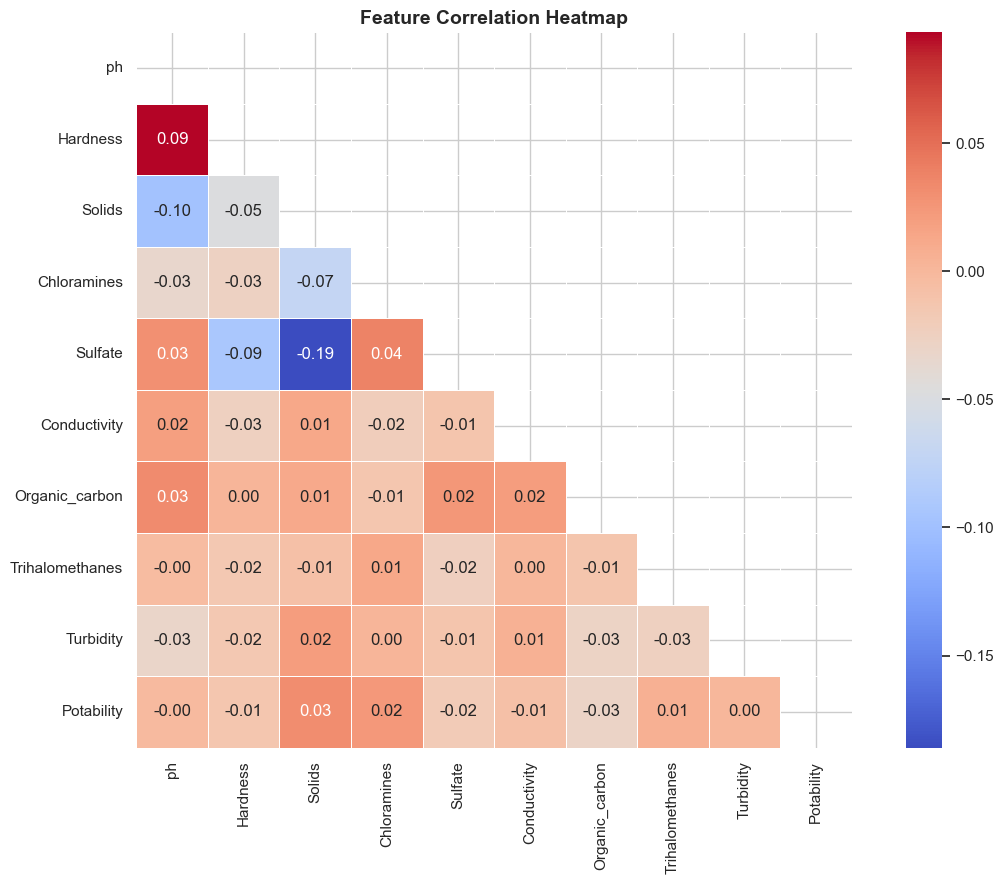

In [30]:
plt.figure(figsize=(12, 9)) 
corr = df[feature_cols + ['Potability']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

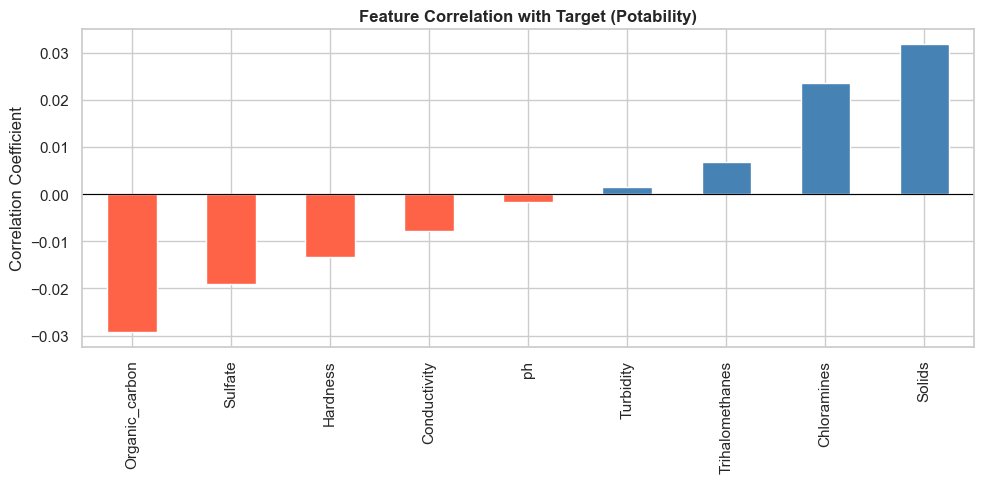

In [31]:
target_corr = df.corr()['Potability'].drop('Potability').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr]
plt.figure(figsize=(10, 5))
target_corr.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Feature Correlation with Target (Potability)', fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

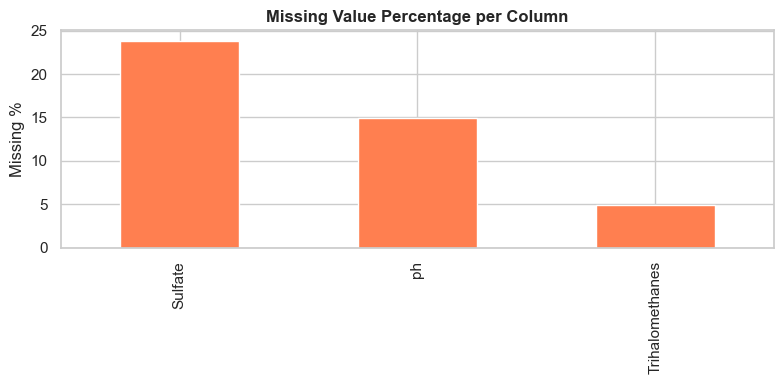

In [32]:
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
plt.figure(figsize=(8, 4))
missing_pct.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Missing Value Percentage per Column', fontweight='bold')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

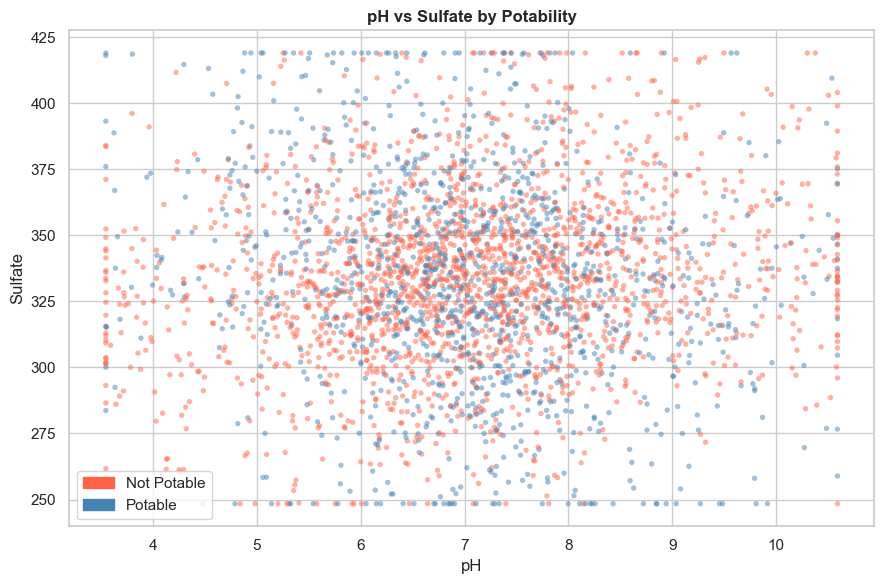

In [33]:
plt.figure(figsize=(9, 6))
colors = df['Potability'].map({0: 'tomato', 1: 'steelblue'})
plt.scatter(df['ph'], df['Sulfate'], c=colors, alpha=0.5, edgecolors='none', s=15)
plt.xlabel('pH')
plt.ylabel('Sulfate')
plt.title('pH vs Sulfate by Potability', fontweight='bold')
from matplotlib.patches import Patch
legend = [Patch(color='tomato', label='Not Potable'), Patch(color='steelblue', label='Potable')]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

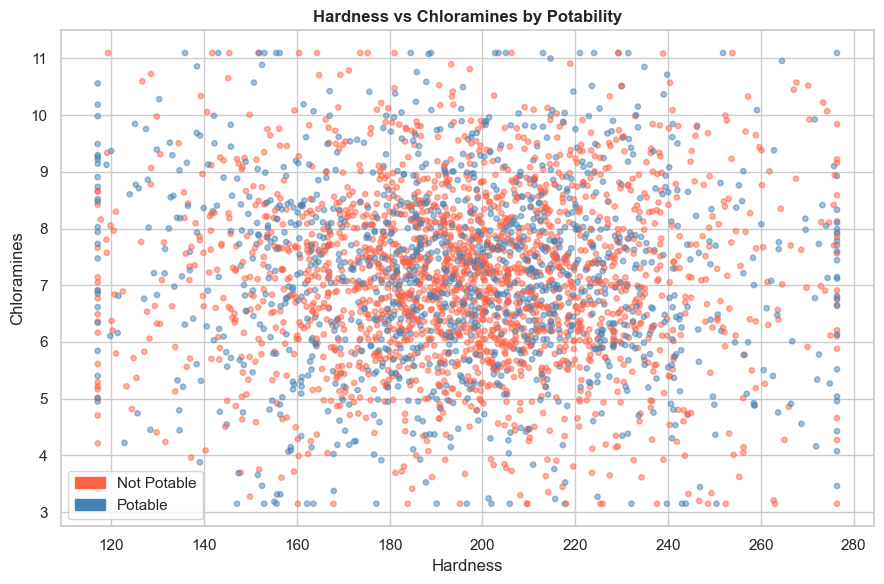

In [34]:
plt.figure(figsize=(9, 6))
colors2 = df['Potability'].map({0: 'tomato', 1: 'steelblue'})
plt.scatter(df['Hardness'], df['Chloramines'], c=colors2, alpha=0.5, s=15)
plt.xlabel('Hardness')
plt.ylabel('Chloramines')
plt.title('Hardness vs Chloramines by Potability', fontweight='bold')
from matplotlib.patches import Patch
legend2 = [Patch(color='tomato', label='Not Potable'), Patch(color='steelblue', label='Potable')]
plt.legend(handles=legend2)
plt.tight_layout()
plt.show()

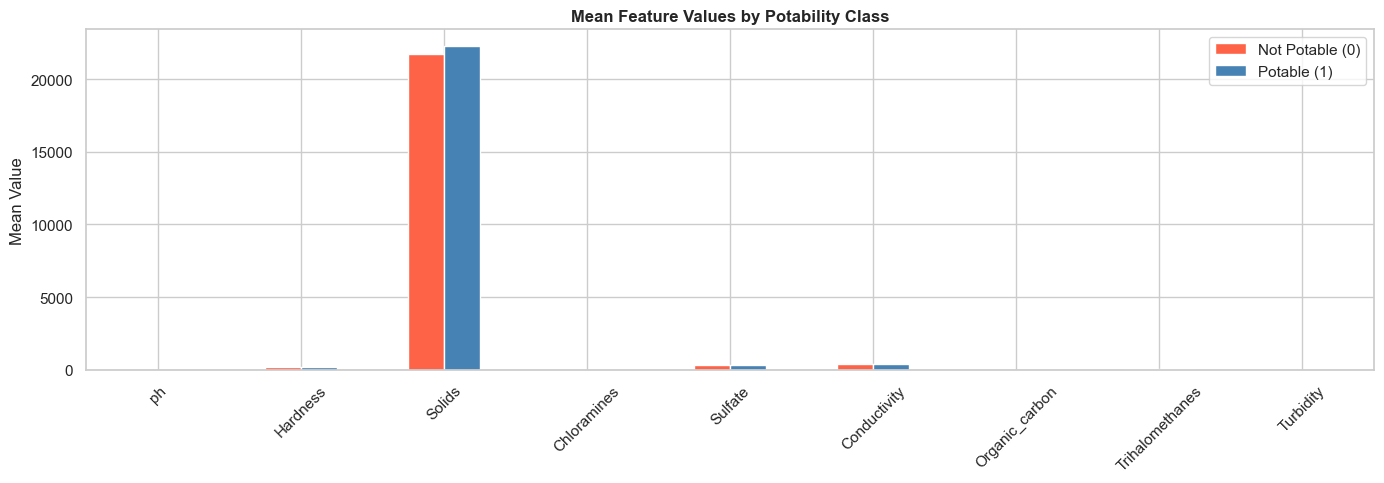

In [35]:
mean_by_class = df.groupby('Potability')[feature_cols].mean()
mean_by_class.T.plot(kind='bar', figsize=(14, 5), color=['tomato','steelblue'])
plt.title('Mean Feature Values by Potability Class', fontweight='bold')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(['Not Potable (0)', 'Potable (1)'])
plt.tight_layout()
plt.show()

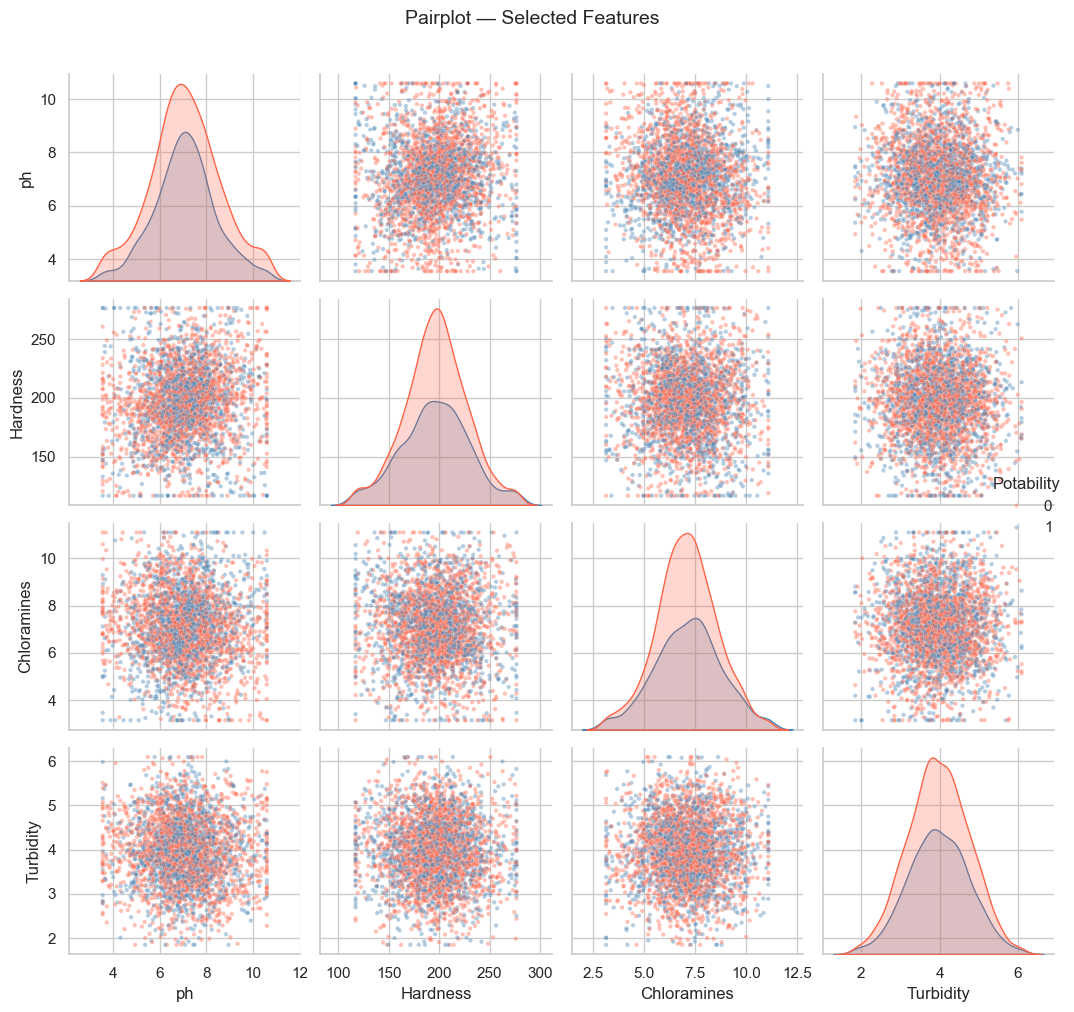

In [36]:
selected = ['ph', 'Hardness', 'Chloramines', 'Turbidity', 'Potability']
g = sns.pairplot(df[selected], hue='Potability',
                 palette={0: 'tomato', 1: 'steelblue'},
                 plot_kws={'alpha': 0.4, 's': 10})
g.fig.suptitle('Pairplot — Selected Features', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

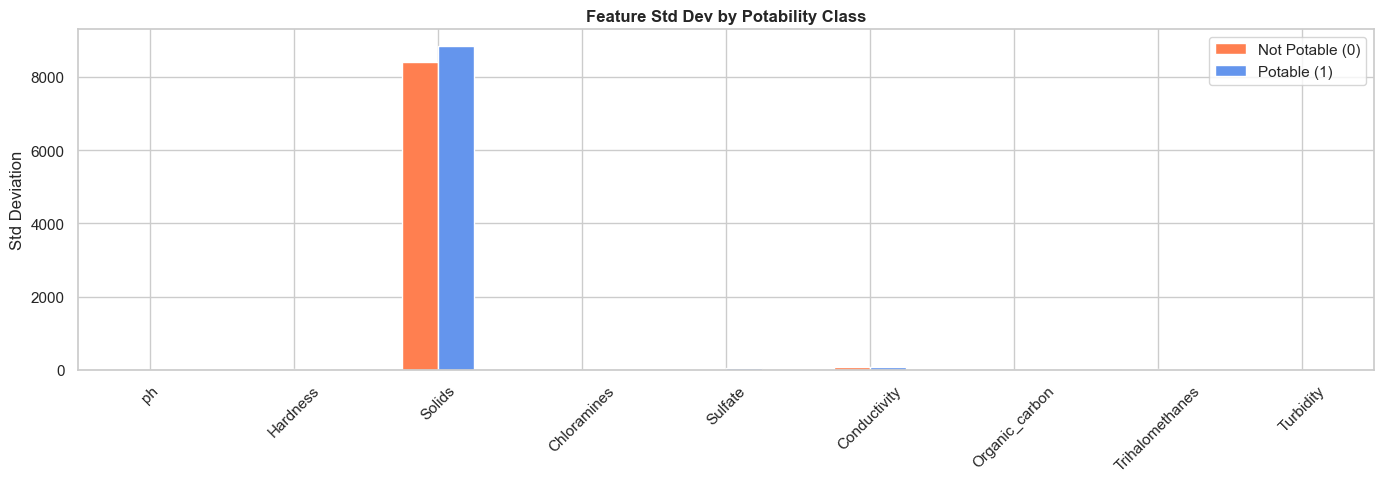

In [37]:
std_by_class = df.groupby('Potability')[feature_cols].std()
std_by_class.T.plot(kind='bar', figsize=(14, 5), color=['coral','cornflowerblue'])
plt.title('Feature Std Dev by Potability Class', fontweight='bold')
plt.ylabel('Std Deviation')
plt.xticks(rotation=45)
plt.legend(['Not Potable (0)', 'Potable (1)'])
plt.tight_layout()
plt.show()

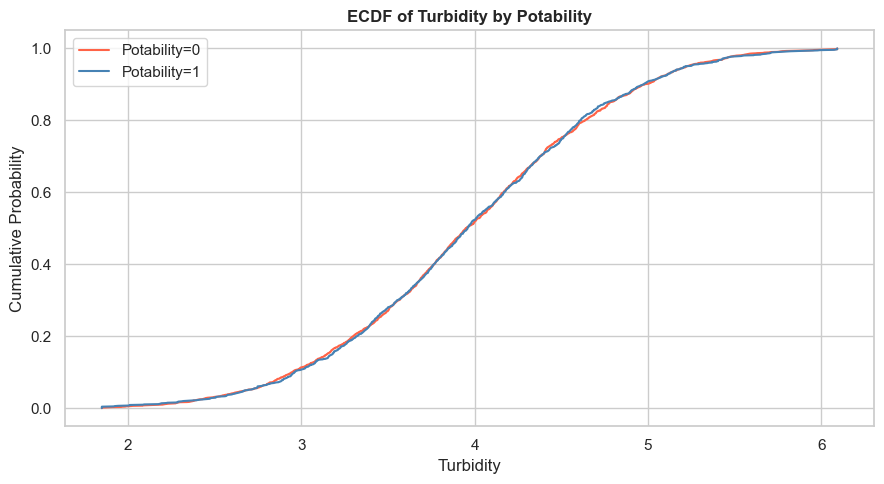

In [38]:
plt.figure(figsize=(9, 5))
for label, color in zip([0, 1], ['tomato', 'steelblue']):
    vals = np.sort(df[df['Potability'] == label]['Turbidity'])
    ecdf = np.arange(1, len(vals)+1) / len(vals)
    plt.plot(vals, ecdf, label=f'Potability={label}', color=color)
plt.xlabel('Turbidity')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Turbidity by Potability', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:

print("=" * 40)
print("  VISUALIZATION SUMMARY")
print("=" * 40)
print(f"  Total plots created : 16")
print(f"  Features visualized : {len(feature_cols)}")
print(f"  Dataset rows        : {len(df)}")
print("  All visualizations complete!")
print("=" * 40)

  VISUALIZATION SUMMARY
  Total plots created : 16
  Features visualized : 9
  Dataset rows        : 3276
  All visualizations complete!
